In [1]:
# Cell 1 - Load, encode, fix dtypes, add interaction term
import pandas as pd
import numpy as np

df = pd.read_csv("insurance.csv")
df = pd.get_dummies(df, drop_first=True, dtype=int)

# Add interaction term BEFORE astype to avoid dtype conflict
df['smoker_bmi'] = df['smoker_yes'] * df['bmi']

# Now convert everything to float64
df = df.astype(float)

# Sanity check
print(df.dtypes)   # all should be float64
print(df.head())

age                 float64
bmi                 float64
children            float64
expenses            float64
sex_male            float64
smoker_yes          float64
region_northwest    float64
region_southeast    float64
region_southwest    float64
smoker_bmi          float64
dtype: object
    age   bmi  children  expenses  sex_male  smoker_yes  region_northwest  \
0  19.0  27.9       0.0  16884.92       0.0         1.0               0.0   
1  18.0  33.8       1.0   1725.55       1.0         0.0               0.0   
2  28.0  33.0       3.0   4449.46       1.0         0.0               0.0   
3  33.0  22.7       0.0  21984.47       1.0         0.0               1.0   
4  32.0  28.9       0.0   3866.86       1.0         0.0               1.0   

   region_southeast  region_southwest  smoker_bmi  
0               0.0               1.0        27.9  
1               1.0               0.0         0.0  
2               1.0               0.0         0.0  
3               0.0               0

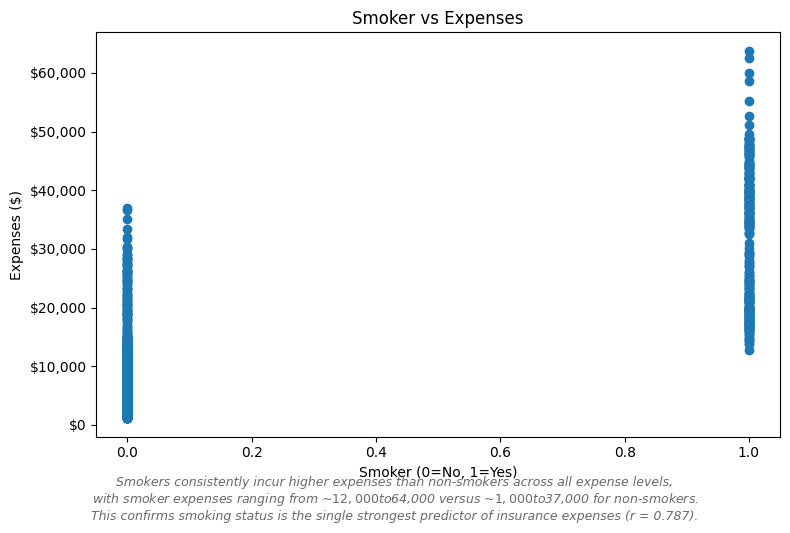

In [2]:
# Cell 2 - Explore: Smoker vs Expenses
import matplotlib.pyplot as plt

# ── Chart 1: Smoker vs Expenses ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['smoker_yes'], df['expenses'])
ax.set_xlabel("Smoker (0=No, 1=Yes)")
ax.set_ylabel("Expenses ($)")
ax.set_title("Smoker vs Expenses")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

fig.text(
    0.5, -0.05,
    "Smokers consistently incur higher expenses than non-smokers across all expense levels,\n"
    "with smoker expenses ranging from ~$12,000 to $64,000 versus ~$1,000 to $37,000 for non-smokers.\n"
    "This confirms smoking status is the single strongest predictor of insurance expenses (r = 0.787).",
    ha='center', fontsize=9, style='italic', color='dimgray'
)

plt.tight_layout()
plt.show()

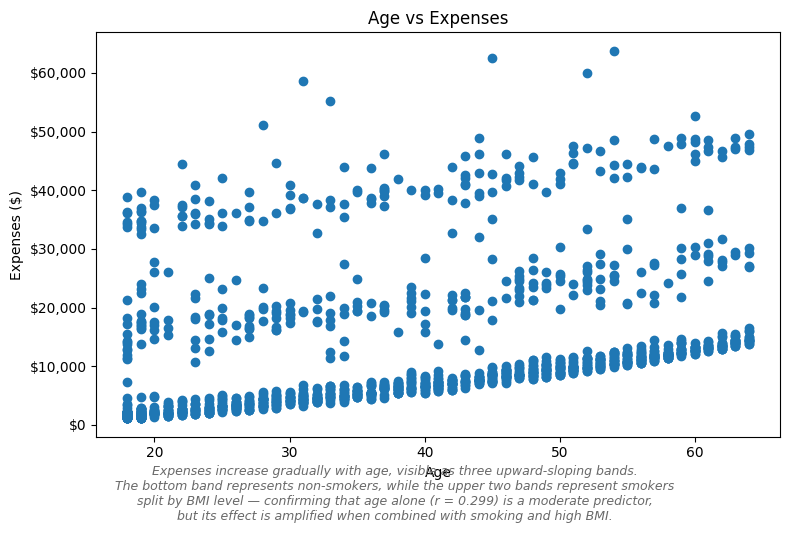

In [3]:
# Cell 3 - Explore: Age vs Expenses
# ── Chart 2: Age vs Expenses ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['age'], df['expenses'])
ax.set_xlabel("Age")
ax.set_ylabel("Expenses ($)")
ax.set_title("Age vs Expenses")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

fig.text(
    0.5, -0.05,
    "Expenses increase gradually with age, visible as three upward-sloping bands.\n"
    "The bottom band represents non-smokers, while the upper two bands represent smokers\n"
    "split by BMI level — confirming that age alone (r = 0.299) is a moderate predictor,\n"
    "but its effect is amplified when combined with smoking and high BMI.",
    ha='center', fontsize=9, style='italic', color='dimgray'
)

plt.tight_layout()
plt.show()

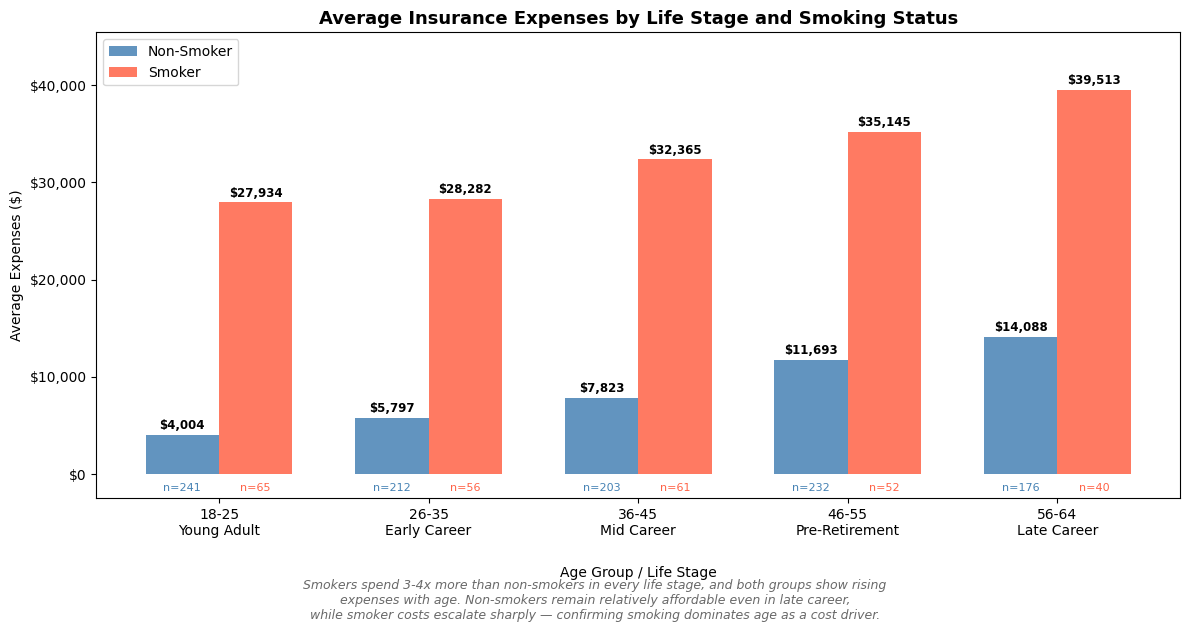


--- Summary Table ---
Age Group             Non-Smoker Avg   Smoker Avg  Smoker − Non-Smoker   NS Count    S Count
------------------------------------------------------------------------------------------
18-25 Young Adult    $        4,004 $     27,934 $            23,930        241         65
26-35 Early Career   $        5,797 $     28,282 $            22,485        212         56
36-45 Mid Career     $        7,823 $     32,365 $            24,542        203         61
46-55 Pre-Retirement $       11,693 $     35,145 $            23,452        232         52
56-64 Late Career    $       14,088 $     39,513 $            25,425        176         40


In [4]:
# Histogram - Age buckets with smoking/non-smoking expenses
import matplotlib.pyplot as plt
import numpy as np

# ── Charts 3: Age group with smoking/non-smoking expenses ────────────────────
bins   = [17, 25, 35, 45, 55, 64]
labels = ['18-25\nYoung Adult',
          '26-35\nEarly Career',
          '36-45\nMid Career',
          '46-55\nPre-Retirement',
          '56-64\nLate Career']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

smokers          = df[df['smoker_yes'] == 1]
non_smokers      = df[df['smoker_yes'] == 0]
smoker_avg       = smokers.groupby('age_group', observed=True)['expenses'].mean()
non_smoker_avg   = non_smokers.groupby('age_group', observed=True)['expenses'].mean()
smoker_count     = smokers.groupby('age_group', observed=True)['expenses'].count()
non_smoker_count = non_smokers.groupby('age_group', observed=True)['expenses'].count()

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, non_smoker_avg, width,
               label='Non-Smoker', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, smoker_avg, width,
               label='Smoker', color='tomato', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'${bar.get_height():,.0f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'${bar.get_height():,.0f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold')

for i, (ns, s) in enumerate(zip(non_smoker_count, smoker_count)):
    ax.text(i - width/2, -1800, f'n={ns}', ha='center',
            fontsize=8, color='steelblue')
    ax.text(i + width/2, -1800, f'n={s}',  ha='center',
            fontsize=8, color='tomato')

ax.set_xlabel('Age Group / Life Stage', labelpad=20)
ax.set_ylabel('Average Expenses ($)')
ax.set_title('Average Insurance Expenses by Life Stage and Smoking Status',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_ylim(-2500, max(smoker_avg.max(), non_smoker_avg.max()) * 1.15)

fig.text(
    0.5, -0.04,
    "Smokers spend 3-4x more than non-smokers in every life stage, and both groups show rising\n"
    "expenses with age. Non-smokers remain relatively affordable even in late career,\n"
    "while smoker costs escalate sharply — confirming smoking dominates age as a cost driver.",
    ha='center', fontsize=9, style='italic', color='dimgray'
)

plt.tight_layout()
plt.show()

# Print summary table
print("\n--- Summary Table ---")
print(f"{'Age Group':<20} {'Non-Smoker Avg':>15} {'Smoker Avg':>12} "
      f"{'Smoker − Non-Smoker':>20} {'NS Count':>10} {'S Count':>10}")
print("-" * 90)
for label, ns_avg, s_avg, ns_n, s_n in zip(
        labels, non_smoker_avg, smoker_avg, non_smoker_count, smoker_count):
    clean_label = label.replace('\n', ' ')
    premium     = s_avg - ns_avg
    print(f"{clean_label:<20} ${ns_avg:>13,.0f} ${s_avg:>11,.0f} "
          f"${premium:>18,.0f} {ns_n:>10} {s_n:>10}")

df.drop(columns=['age_group'], inplace=True)

In [5]:
# Cell 5 - Correlation matrix
print(df.corr())

                       age       bmi  children  expenses  sex_male  \
age               1.000000  0.109341  0.042469  0.299008 -0.020856   
bmi               0.109341  1.000000  0.012645  0.198576  0.046380   
children          0.042469  0.012645  1.000000  0.067998  0.017163   
expenses          0.299008  0.198576  0.067998  1.000000  0.057292   
sex_male         -0.020856  0.046380  0.017163  0.057292  1.000000   
smoker_yes       -0.025019  0.003968  0.007673  0.787251  0.076185   
region_northwest -0.000407 -0.135992  0.024806 -0.039905 -0.011156   
region_southeast -0.011642  0.270144 -0.023066  0.073982  0.017117   
region_southwest  0.010016 -0.006398  0.021914 -0.043210 -0.004184   
smoker_bmi       -0.018363  0.109005  0.006243  0.845155  0.089086   

                  smoker_yes  region_northwest  region_southeast  \
age                -0.025019         -0.000407         -0.011642   
bmi                 0.003968         -0.135992          0.270144   
children            0.007

In [6]:
# Cell 6 - Train linear regression model

import warnings
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop("expenses", axis=1).astype(np.float64)
y = df["expenses"].astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    model = LinearRegression()
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)

print("Score:", score)

Score: 0.8652594453714388
